In [1]:
import SF_26
# import Model2
import Model3
import Model4
import matplotlib.pyplot as plt
import numpy
import random
import json
import networkx as nx
import seaborn as sns
# import Simulation as Sim

In [2]:
def plot(opinion_history, time_steps, num_nodes):
    doc_1 = []
    for i in time_steps:
        doc_1.append(numpy.average(opinion_history[i]))
    plt.figure(figsize=(12, 8))
    for node_idx in range(num_nodes):
        opinion_values = [opinions[node_idx] for opinions in opinion_history]
        plt.plot(time_steps, opinion_values, alpha=0.1, color = "grey")
    plt.plot(time_steps, doc_1, alpha = 1, color = "black")
    plt.xlabel('Iteration', fontsize =25)
    plt.ylabel('Opinion', fontsize=25)
    plt.title('Opinion Dynamics Over Time',fontsize=25)
    plt.xticks(fontsize=25)
    plt.yticks(fontsize=25)
    plt.legend(fontsize=25)
    plt.legend()
    plt.grid(True)
    plt.show()

In [2]:
def count_extreme_opinions(opinions):
    above_0_8 = sum(1 for opinion in opinions if opinion > 0.8)
    below_0_2 = sum(1 for opinion in opinions if opinion < 0.2)
    return above_0_8, below_0_2

In [3]:
def sim(G, max_iteration):
    num_iteration = 0
    opinion_history = []
    # while num_iteration < max_iteration:
    while num_iteration < max_iteration and not G.consensus_reached(0.001) and not G.opinions_stabilized(0.0000001):
        for node in G.graph.nodes():
            neighbors = list(G.graph.neighbors(node))
                
            weighted_sum = sum(G.weight_matrix[node][n] * G.agents[n].opinion for n in neighbors)
            new_opinion = weighted_sum / sum(G.weight_matrix[node][n] for n in neighbors)
            G.agents[node].opinion = new_opinion
        num_iteration += 1
        opinions_snapshot = [G.agents[node].opinion for node in G.graph.nodes()]
        opinion_history.append(opinions_snapshot)
    num_nodes = G.num_of_nodes
    time_steps = range(num_iteration)
    return opinion_history, num_nodes, time_steps

Test-PBNetwork

In [4]:
random_state = numpy.random.RandomState(42)
G = SF_26.SFNetwork(100, 1000, 0, 20, 0, 100, 0, random_state)
opinion_history, num_nodes, time_steps = sim(G, 1000)

In [ ]:
rounds = 100
E1_aveopinion_0 = []
ave_time_0 = []
# E1_aveopinion_20 = []
# E1_aveopinion_40 = []
# E1_aveopinion_60 = []
# E1_aveopinion_80 = []
# E1_aveopinion_100 = []
max_iteration = 2000
for s in range(rounds):
    ave_single_sim = []
    random_state = numpy.random.RandomState(s)
    G = SF_26.SFNetwork(100, 1000, 0, 20, 0, 0, 0, random_state)
    opinion_history, num_nodes, time_steps = sim(G, max_iteration)
    ave_time_0.append(time_steps)
    for item in opinion_history:
        ave_single_sim.append(sum(item)/len(item))
    E1_aveopinion_0.append(ave_single_sim)
mean_opinion_0 = numpy.mean(E1_aveopinion_0, axis=0)
std_opinion_0 = numpy.std(E1_aveopinion_0, axis=0)

In [ ]:
rounds = 100
E1_aveopinion_50 = []
ave_time_50 = []
# E1_aveopinion_20 = []
# E1_aveopinion_40 = []
# E1_aveopinion_60 = []
# E1_aveopinion_80 = []
# E1_aveopinion_100 = []
max_iteration = 2000
for s in range(rounds):
    ave_single_sim = []
    random_state = numpy.random.RandomState(s)
    G = SF_26.SFNetwork(100, 1000, 0, 20, 0, 50, 0, random_state)
    opinion_history, num_nodes, time_steps = sim(G, max_iteration)
    ave_time_50.append(time_steps)
    for item in opinion_history:
        ave_single_sim.append(sum(item)/len(item))
    E1_aveopinion_50.append(ave_single_sim)
mean_opinion_50 = numpy.mean(E1_aveopinion_50, axis=0)
std_opinion_50 = numpy.std(E1_aveopinion_50, axis=0)

In [13]:
rounds = 100
E1_aveopinion_100 = []
ave_time_100 = []
# E1_aveopinion_20 = []
# E1_aveopinion_40 = []
# E1_aveopinion_60 = []
# E1_aveopinion_80 = []
# E1_aveopinion_100 = []
max_iteration =2000
for s in range(rounds):
    ave_single_sim = []
    random_state = numpy.random.RandomState(42)
    G = SF_26.SFNetwork(100, 1000, 0, 20, 0, 100, 0, random_state)
    opinion_history, num_nodes, time_steps = sim(G, max_iteration)
    ave_time_100.append(time_steps)
    for item in opinion_history:
        ave_single_sim.append(sum(item)/len(item))
    E1_aveopinion_100.append(ave_single_sim)
mean_opinion_100 = numpy.mean(E1_aveopinion_100, axis=0)
std_opinion_100 = numpy.std(E1_aveopinion_100, axis=0)

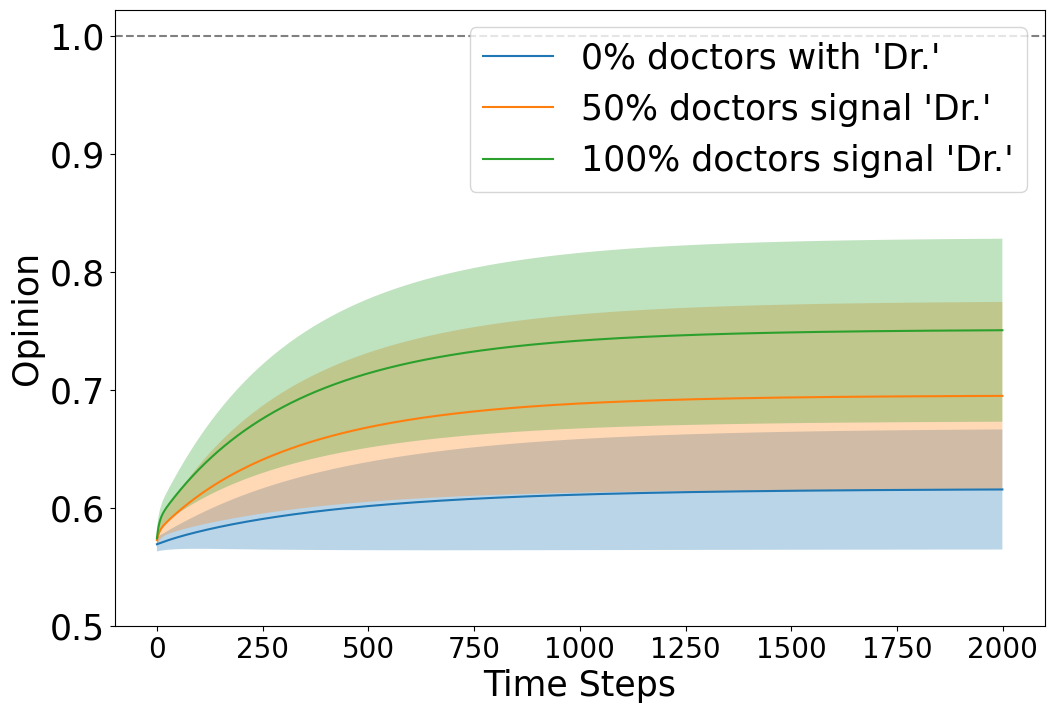

In [27]:
plt.figure(figsize=(12, 8))
plt.plot(mean_opinion_0, label="0% doctors with 'Dr.'")
plt.plot(mean_opinion_50, label="50% doctors signal 'Dr.'")
plt.plot(mean_opinion_100, label="100% doctors signal 'Dr.'")
# plt.fill_between(range(max_iteration), mean_opinion_s6 - std_opinion_s6, mean_opinion_s6 + std_opinion_s6, alpha=0.3, label='S6: ±1 Std Dev')
plt.fill_between(range(max_iteration), mean_opinion_0 - std_opinion_0, mean_opinion_0 + std_opinion_0, alpha=0.3)
plt.fill_between(range(max_iteration), mean_opinion_50 - std_opinion_50, mean_opinion_50 + std_opinion_50, alpha=0.3)
plt.fill_between(range(max_iteration), mean_opinion_100 - std_opinion_100, mean_opinion_100 + std_opinion_100, alpha=0.3)
plt.axhline(y = 1, color = 'grey', linestyle = 'dashed')
plt.xlabel('Time Steps', fontsize =25)
plt.ylabel('Opinion', fontsize=25)
# plt.title('E1 - Average Opinion Over Time on the SF network',fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)
plt.legend(fontsize=25)
plt.ylim(bottom=0.5)
# plt.grid(True)
plt.show()

In [9]:
n_bot = [0, 100, 200, 300, 400]
n_titled_bots_per = [0, 0.25, 0.5, 0.75, 1]
heatmap_average = numpy.zeros((len(n_bot), len(n_titled_bots_per)))
heatmap_0_8 = numpy.zeros((len(n_bot), len(n_titled_bots_per)))
heatmap_0_2 = numpy.zeros((len(n_bot), len(n_titled_bots_per)))

max_iteration = 2000
rounds = 10

for i in range(len(n_bot)):
    for j in range(len(n_titled_bots_per)):
        avg_total = 0
        avg_0_8 = 0
        avg_0_2 = 0
        
        for run in range(rounds):
            random_state = numpy.random.RandomState(run)  # Different seed per run
            G = SF_26.SFNetwork(
                100,
                1400 - n_bot[i],
                n_bot[i],
                30,
                0,
                100,
                int(n_bot[i] * n_titled_bots_per[j]),
                random_state
            )
            opinion_history, num_nodes, time_steps = sim(G, max_iteration)
            above_0_8, below_0_2 = count_extreme_opinions(opinion_history[-1])
            avg_total += (sum(opinion_history[-1]) - 100) / (1400 - n_bot[i])
            avg_0_8 += (above_0_8 - 100) / (1400 - n_bot[i])
            avg_0_2 += (below_0_2 - n_bot[i]) / (1400 - n_bot[i])
        
        heatmap_average[i, j] = avg_total / rounds
        heatmap_0_8[i, j] = avg_0_8 / rounds
        heatmap_0_2[i, j] = avg_0_2 / rounds

In [ ]:
n_bot = [0, 100, 200, 300, 400]
n_titled_bots_per = [0, 0.25, 0.5, 0.75, 1]
heatmap_average = numpy.zeros((len(n_bot), len(n_titled_bots_per)))
heatmap_0_8 = numpy.zeros((len(n_bot), len(n_titled_bots_per)))
heatmap_0_2 = numpy.zeros((len(n_bot), len(n_titled_bots_per)))

max_iteration = 2000
rounds = 50

for i in range(len(n_bot)):
    for j in range(len(n_titled_bots_per)):
        avg_total = 0
        avg_0_8 = 0
        avg_0_2 = 0
        
        for run in range(rounds):
            random_state = numpy.random.RandomState(run) 
            G = SF_26.SFNetwork(
                100,
                1400 - n_bot[i],
                n_bot[i],
                30,
                0,
                100,
                int(n_bot[i] * n_titled_bots_per[j]),
                random_state
            )
            opinion_history, num_nodes, time_steps = sim(G, max_iteration)
            above_0_8, below_0_2 = count_extreme_opinions(opinion_history[-1])
            avg_total += (sum(opinion_history[-1]) - 100) / (1400 - n_bot[i])
            avg_0_8 += (above_0_8 - 100) / (1400 - n_bot[i])
            avg_0_2 += (below_0_2 - n_bot[i]) / (1400 - n_bot[i])
        
        heatmap_average[i, j] = avg_total / rounds
        heatmap_0_8[i, j] = avg_0_8 / rounds
        heatmap_0_2[i, j] = avg_0_2 / rounds

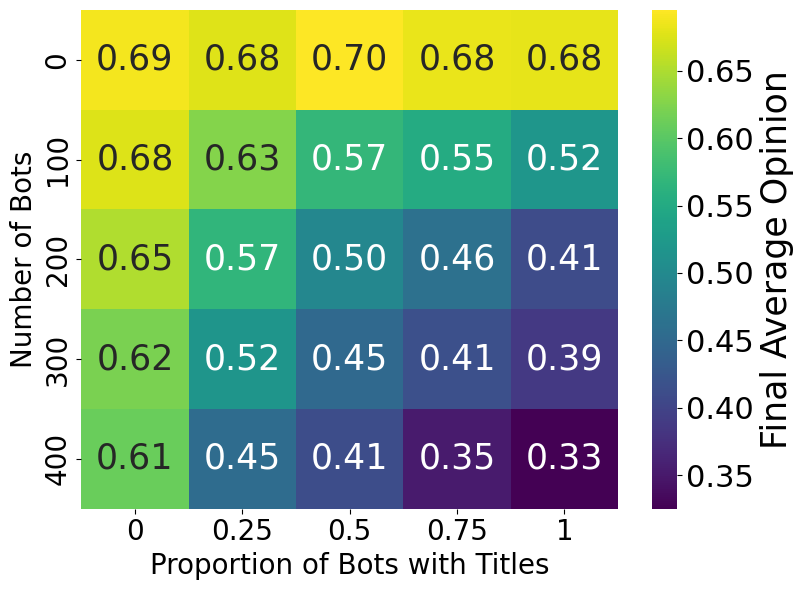

In [25]:
n_bot = [0, 100, 200, 300, 400]
n_titled_bots_per = [0, 0.25, 0.5, 0.75, 1]

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    heatmap_average,
    xticklabels=n_titled_bots_per,
    yticklabels=n_bot,
    cmap='viridis',
    annot=True,
    annot_kws={"size": 25},
    fmt=".2f",
    cbar_kws={'label': 'Final Average Opinion'}
)
plt.xlabel('Proportion of Bots with Titles', fontsize=20)
plt.ylabel('Number of Bots', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.title('The Final Average Opinion of Common Users in E2', fontsize=18)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=22) 
cbar.set_label('Final Average Opinion', fontsize=25)

plt.tight_layout()
plt.show()

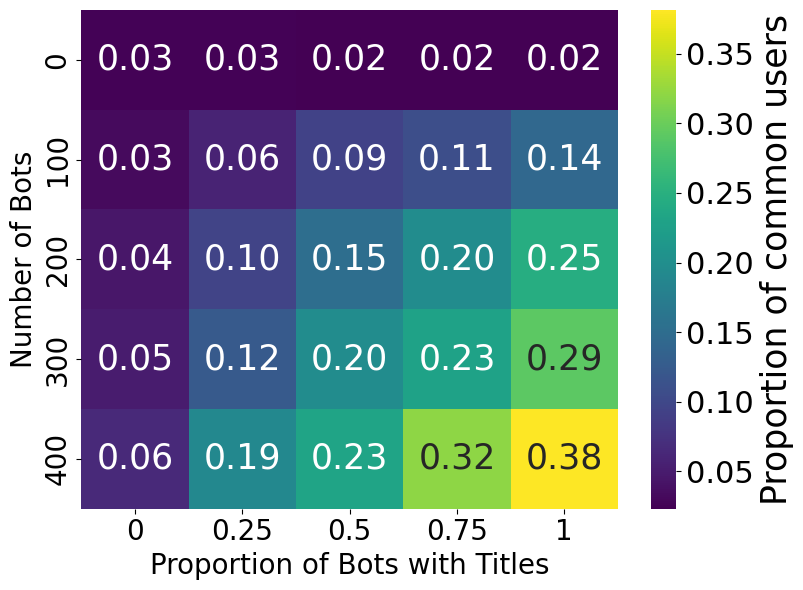

In [23]:
plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    heatmap_0_2,
    xticklabels=n_titled_bots_per,
    yticklabels=n_bot,
    cmap='viridis',
    annot=True,
    annot_kws={"size": 25},
    fmt=".2f",
    cbar_kws={'label': 'proportion of common users'}
)

plt.xlabel('Proportion of Bots with Titles', fontsize=20)
plt.ylabel('Number of Bots', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.title('Proportion of Common Users Tending to Trust Misinformation', fontsize=18)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=22)  
cbar.set_label('Proportion of common users', fontsize=25)

plt.tight_layout()
plt.show()

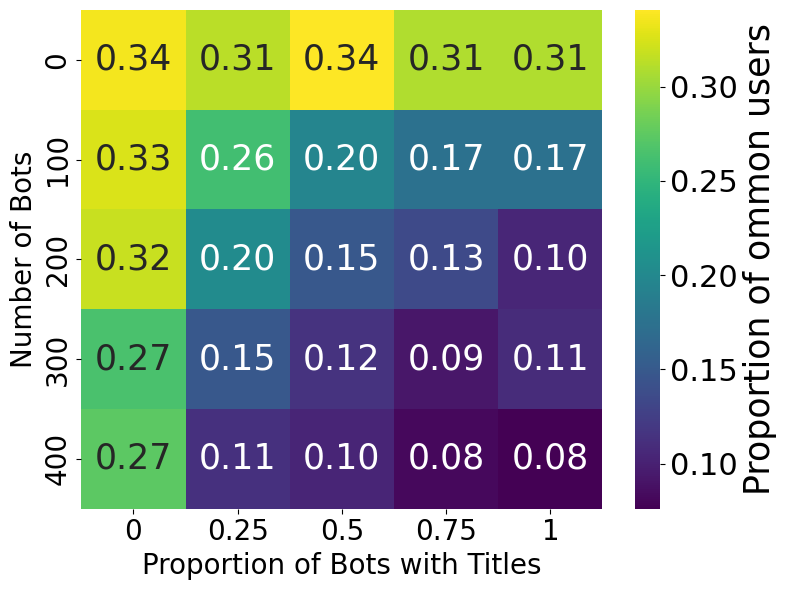

In [26]:
plt.figure(figsize=(8, 6))

# Draw heatmap and capture the axis
ax = sns.heatmap(
    heatmap_0_8,
    xticklabels=n_titled_bots_per,
    yticklabels=n_bot,
    cmap='viridis',
    annot=True,
    annot_kws={"size": 25},
    fmt=".2f",
    cbar_kws={'label': 'proportion of common users'}
)

# Set axis labels and title
plt.xlabel('Proportion of Bots with Titles', fontsize=20)
plt.ylabel('Number of Bots', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.title('Proportion of Common users Tending to Trust Verified Information', fontsize=18)

# Adjust colorbar font size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=22)  # tick labels
cbar.set_label('Proportion of ommon users', fontsize=25)

plt.tight_layout()
plt.show()

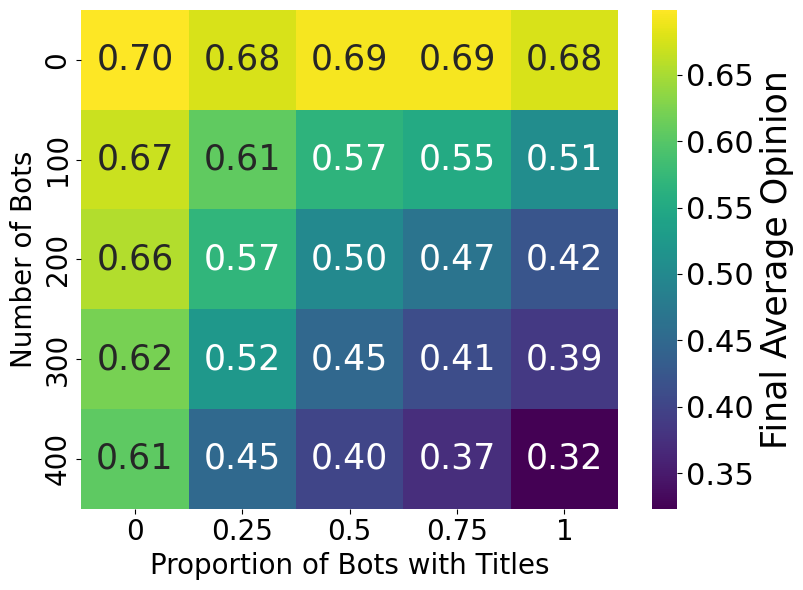

In [18]:
n_bot = [0, 100, 200, 300, 400]
n_titled_bots_per = [0, 0.25, 0.5, 0.75, 1]

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    heatmap_average,
    xticklabels=n_titled_bots_per,
    yticklabels=n_bot,
    cmap='viridis',
    annot=True,
    annot_kws={"size": 25},
    fmt=".2f",
    cbar_kws={'label': 'Final Average Opinion'}
)
plt.xlabel('Proportion of Bots with Titles', fontsize=20)
plt.ylabel('Number of Bots', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.title('The Final Average Opinion of Common Users in E2', fontsize=18)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=22) 
cbar.set_label('Final Average Opinion', fontsize=25)

plt.tight_layout()
plt.show()

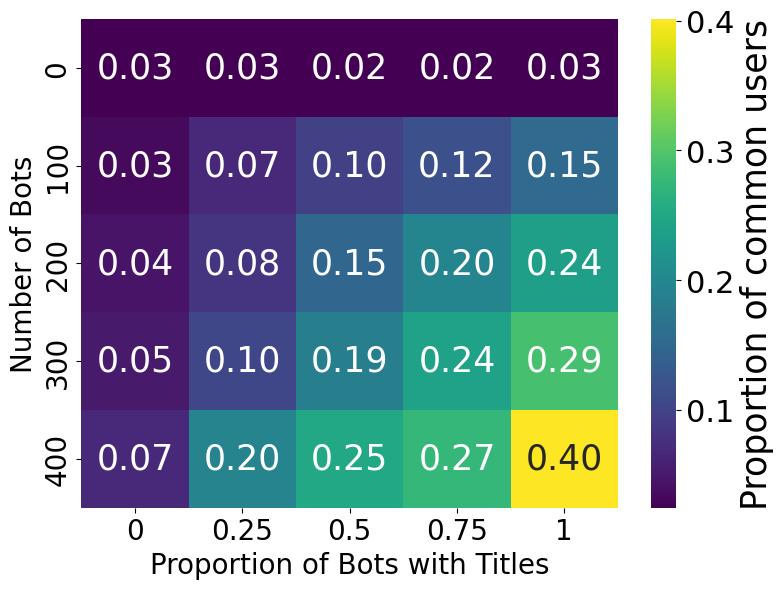

In [19]:
plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    heatmap_0_2,
    xticklabels=n_titled_bots_per,
    yticklabels=n_bot,
    cmap='viridis',
    annot=True,
    annot_kws={"size": 25},
    fmt=".2f",
    cbar_kws={'label': 'proportion of common users'}
)

plt.xlabel('Proportion of Bots with Titles', fontsize=20)
plt.ylabel('Number of Bots', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.title('Proportion of Common Users Tending to Trust Misinformation', fontsize=18)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=22)  
cbar.set_label('Proportion of common users', fontsize=25)

plt.tight_layout()
plt.show()

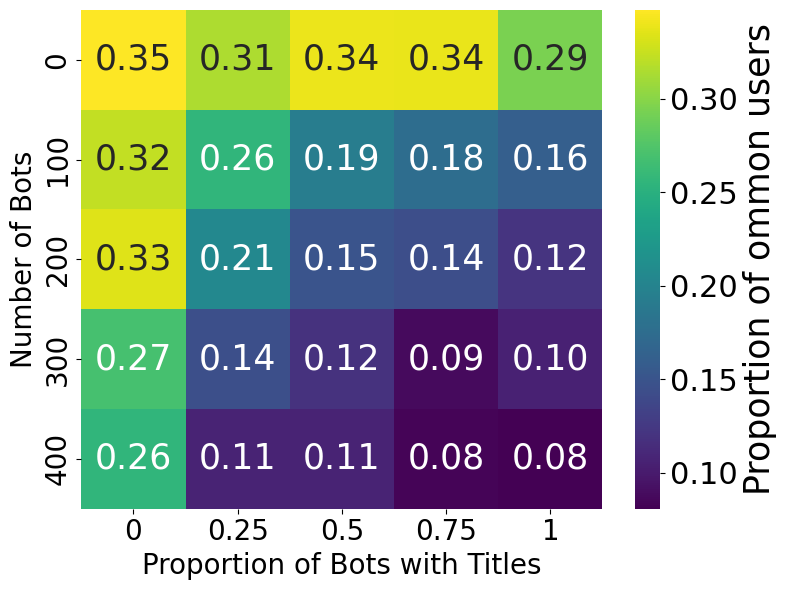

In [20]:
plt.figure(figsize=(8, 6))

# Draw heatmap and capture the axis
ax = sns.heatmap(
    heatmap_0_8,
    xticklabels=n_titled_bots_per,
    yticklabels=n_bot,
    cmap='viridis',
    annot=True,
    annot_kws={"size": 25},
    fmt=".2f",
    cbar_kws={'label': 'proportion of common users'}
)

# Set axis labels and title
plt.xlabel('Proportion of Bots with Titles', fontsize=20)
plt.ylabel('Number of Bots', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.title('Proportion of Common users Tending to Trust Verified Information', fontsize=18)

# Adjust colorbar font size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=22)  # tick labels
cbar.set_label('Proportion of ommon users', fontsize=25)

plt.tight_layout()
plt.show()

In [26]:
import json

# Convert numpy arrays to lists
data_to_store = {
    "E1_aveopinion_100": E1_aveopinion_100,
    "E1_aveopinion_50": E1_aveopinion_50,
    "E1_aveopinion_0": E1_aveopinion_0
}

# Save to file
with open("E1_SF_opinions_data.json", "w") as f:
    json.dump(data_to_store, f)

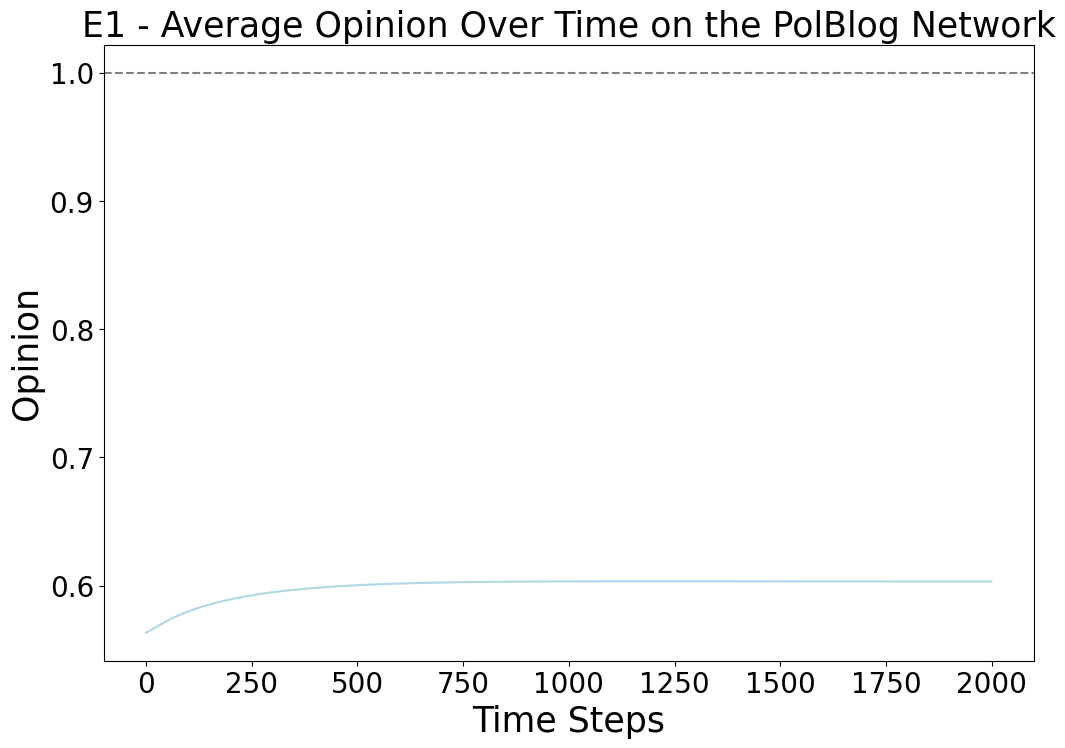

In [8]:
plt.figure(figsize=(12, 8))
for n in range(rounds):
    plt.plot(range(2000), E1_aveopinion_0[n], alpha = 1, color = "lightblue", label = "0%")
    # plt.plot(range(1000), E1_aveopinion_50[n], alpha = 1, color = "pink", label = "50%")
    # plt.plot(range(1000), E1_aveopinion_100[n], alpha = 1, color = "yellow", label = "100%")
    # plt.plot(range(ave_time_40[n]), E1_aveopinion_40[n], alpha = 0.1, color = "yellow", label = "40%")
    # plt.plot(range(ave_time_60[n]), E1_aveopinion_60[n], alpha = 0.1, color = "lightblue", label = "60%")
    # plt.plot(range(ave_time_80[n]), E1_aveopinion_80[n], alpha = 0.1, color = "lightgreen", label = "80%")
    # plt.plot(range(ave_time_100[n]), E1_aveopinion_100[n], alpha = 0.1, color = "purple", label = "100%")
average_time = numpy.average(ave_time_0)
# plt.axvline(x = numpy.average(ave_time_0), color = 'grey', linestyle = 'dashed')
# plt.axvline(x = numpy.average(ave_time_50), color = 'grey', linestyle = 'dashed')
# plt.axvline(x = numpy.average(ave_time_40), color = 'grey', linestyle = 'dashed')
# plt.axvline(x = numpy.average(ave_time_60), color = 'grey', linestyle = 'dashed')
# plt.axvline(x = numpy.average(ave_time_80), color = 'grey', linestyle = 'dashed')
# plt.axvline(x = numpy.average(ave_time_100), color = 'grey', linestyle = 'dashed')
# plt.annotate(numpy.average(ave_time_0), xy=(ave_time_0[n],1),size = 20)
# plt.annotate(numpy.average(ave_time_20), xy=(ave_time_20[n],1),size = 20)
# plt.annotate(numpy.average(ave_time_100), xy=(ave_time_100[n],1),size = 20)
# plt.annotate(numpy.average(ave_time_40), xy=(ave_time_40[n],0.8),size = 10)
plt.axhline(y = 1, color = 'grey', linestyle = 'dashed')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Time Steps', fontsize = 25)
plt.ylabel('Opinion', fontsize = 25)
plt.title('E1 - Average Opinion Over Time on the PolBlog Network', fontsize = 25)
# plt.legend(fontsize = 25)
plt.show()

In [ ]:
n_bot = [0, 100, 200, 300, 400]
n_titled_bots_per = [0, 0.25, 0.5, 0.75, 1]
heatmap_0_8 = numpy.zeros((len(n_bot), len(n_titled_bots_per)))
heatmap_0_2 = numpy.zeros((len(n_bot), len(n_titled_bots_per)))
max_iteration = 10
for i in range(5):
    for j in range(5):
        random_state = numpy.random.RandomState(42)
        G = SF_26.SFNetwork(100, 1000, n_bot[i], 20, 0, 100, int(n_bot[i]*n_titled_bots_per[j]), random_state)
        opinion_history, num_nodes, time_steps = sim(G, max_iteration)
        above_0_8, below_0_2 = count_extreme_opinions(opinion_history[-1])
        heatmap_0_8[i,j] = above_0_8
        heatmap_0_2[i,j] = below_0_2


In [12]:
def heat_map_plot(heatmap_data, n_bot, n_titled_bots_per):
    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_data, xticklabels=n_titled_bots_per, yticklabels=n_bot, 
                cmap='viridis', annot=True, fmt=".2f", cbar_kws={'label': '% Extreme Opinions'})

    plt.xlabel('Proportion of Bots with Titles')
    plt.ylabel('Number of Bots')
    plt.title('Heatmap of Extreme Opinions')
    plt.tight_layout()
    plt.show()

In [13]:
# num_doc = 100
# num_NonDoc = 900
max_iteration = 3000
random_state = numpy.random.RandomState(42)
G = SF_26.SFNetwork(100, 1000, 400, 20, 0, 100, 0, random_state)
num_iteration = 0
opinion_history = []
# while num_iteration < max_iteration:
while num_iteration < max_iteration and not G.consensus_reached(0.001):
    for node in G.graph.nodes():
        neighbors = list(G.graph.neighbors(node))
            
        weighted_sum = sum(G.weight_matrix[node][n] * G.agents[n].opinion for n in neighbors)
        new_opinion = weighted_sum / sum(G.weight_matrix[node][n] for n in neighbors)
        G.agents[node].opinion = new_opinion
    num_iteration += 1
    opinions_snapshot = [G.agents[node].opinion for node in G.graph.nodes()]
    opinion_history.append(opinions_snapshot)
num_nodes = G.num_of_nodes
time_steps = range(num_iteration)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


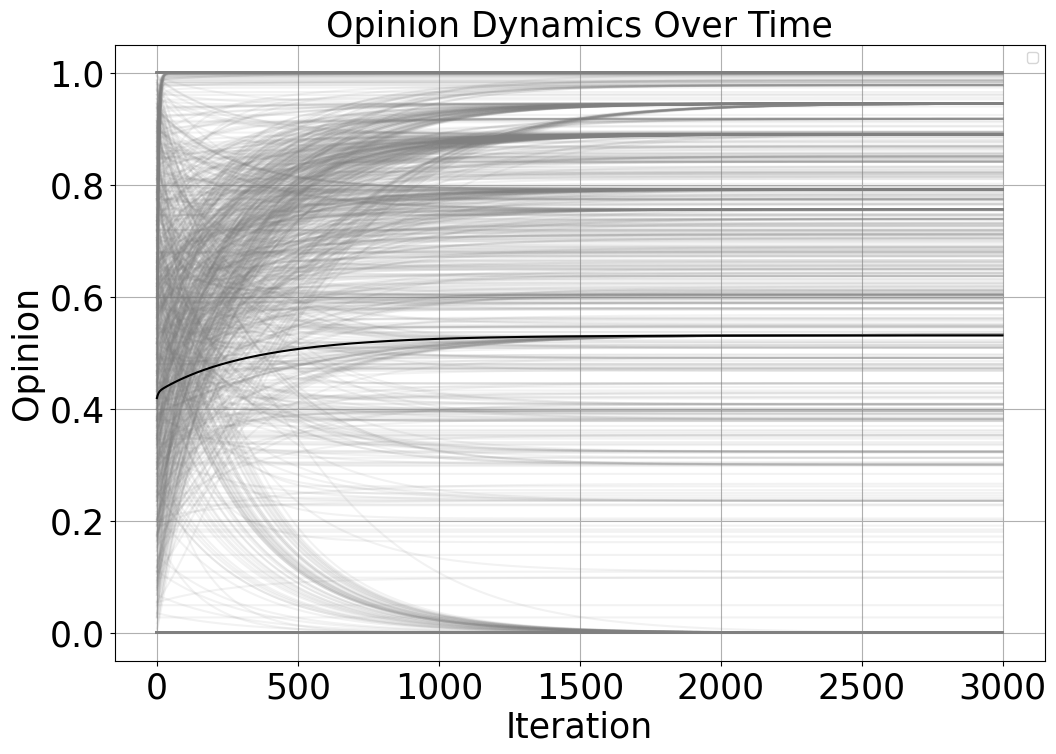

In [14]:
plot(opinion_history, max_iteration)

In [23]:
G_twitter = nx.DiGraph()

# 2. Read the txt file and add edges
with open('soc-twitter-follows.txt', 'r') as f:
    for line in f:
        start, end = map(int, line.strip().split())
        G_twitter.add_edge(start, end)

# 3. (Optional) Print basic info
print(f"Number of nodes: {G_twitter.number_of_nodes()}")
print(f"Number of edges: {G_twitter.number_of_edges()}")

Number of nodes: 404719
Number of edges: 713319


In [35]:
def extract_subgraph(G, size=1000):
    """Extract a smaller subgraph for analysis"""
    # Get nodes with highest degrees
    degrees = dict(G.degree())
    top_nodes = sorted(degrees.keys(), key=lambda x: degrees[x], reverse=True)[:size//10]
    
    # Add their neighbors
    subgraph_nodes = set(top_nodes)
    for node in top_nodes:
        neighbors = list(G.neighbors(node)) + list(G.predecessors(node))
        subgraph_nodes.update(neighbors)
        if len(subgraph_nodes) >= size:
            break
    
    # Create subgraph
    subgraph_nodes = list(subgraph_nodes)[:size]
    subG = G.subgraph(subgraph_nodes).copy()
    subG = nx.convert_node_labels_to_integers(subG, first_label=0, ordering='default')
    
    print(f"Extracted subgraph with {subG.number_of_nodes()} nodes and {subG.number_of_edges()} edges")
    return subG

In [36]:
small_G = extract_subgraph(G_twitter, size=5000)

Extracted subgraph with 5000 nodes and 12384 edges


In [37]:
max_iteration = 2000
random_state = numpy.random.RandomState(42)
G = SF_26.SFNetwork(small_G, 500, 4000, 500, 500, 0, 0, random_state)
num_iteration = 0
opinion_history = []
# while num_iteration < max_iteration:
while num_iteration < max_iteration and not G.consensus_reached(0.001):
    for node in G.graph.nodes():
        neighbors = list(G.graph.neighbors(node))
            
        weighted_sum = sum(G.weight_matrix[node][n] * G.agents[n].opinion for n in neighbors)
        new_opinion = weighted_sum / sum(G.weight_matrix[node][n] for n in neighbors)
        G.agents[node].opinion = new_opinion
    num_iteration += 1
    opinions_snapshot = [G.agents[node].opinion for node in G.graph.nodes()]
    opinion_history.append(opinions_snapshot)
num_nodes = G.num_of_nodes
time_steps = range(num_iteration)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


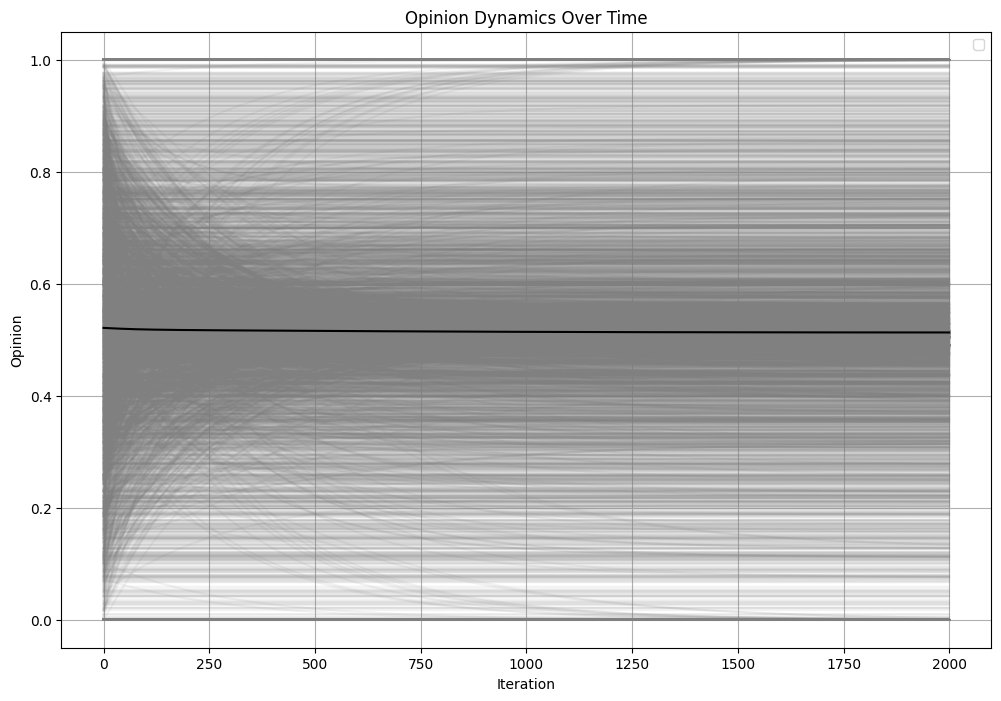

In [38]:
plot(opinion_history, max_iteration)

In [18]:
max_iteration = 10000
random_state = numpy.random.RandomState(42)
G = SF_26.SFNetwork(100, 1400, 0, 50, 0, 0, random_state)
num_iteration = 0
opinion_history = []
# while num_iteration < max_iteration:

while num_iteration < max_iteration and not G.consensus_reached(0.001):
    if num_iteration % 5 == 0:
        G.boost_doctor_visibility()
    if (num_iteration-1) % 5 == 0:
        G.remove_doctor_boost()
    for node in G.graph.nodes():
        neighbors = list(G.graph.neighbors(node))
            
        weighted_sum = sum(G.weight_matrix[node][n] * G.agents[n].opinion for n in neighbors)
        new_opinion = weighted_sum / sum(G.weight_matrix[node][n] for n in neighbors)
        G.agents[node].opinion = new_opinion
    
    opinions_snapshot = [G.agents[node].opinion for node in G.graph.nodes()]
    opinion_history.append(opinions_snapshot)
    num_iteration += 1
num_nodes = G.num_of_nodes
time_steps = range(num_iteration)

In [19]:
print(time_steps)

range(0, 9406)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


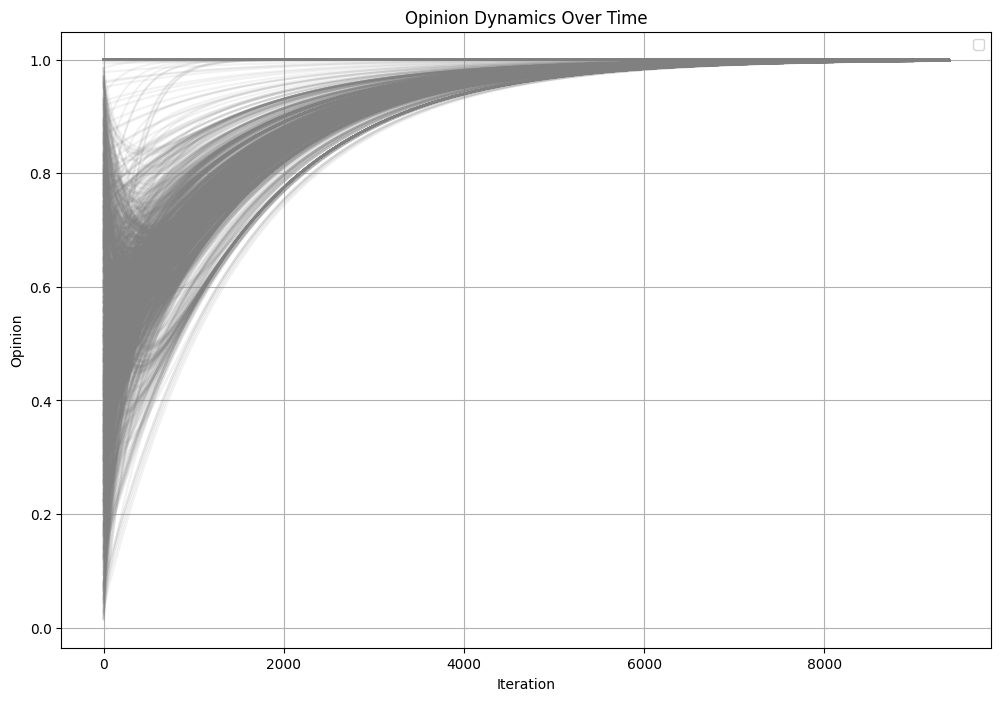

In [14]:
plot(opinion_history, max_iteration)

In [15]:
max_iteration = 10000
random_state = numpy.random.RandomState(42)
G = SF_26.SFNetwork(100, 1400, 0, 50, 0, 0, random_state)
num_iteration = 0
opinion_history = []
# while num_iteration < max_iteration:
G.boost_doctor_visibility()
while num_iteration < max_iteration and not G.consensus_reached(0.001):
    # if num_iteration % 5 == 0:
    #     G.boost_doctor_visibility()
    # if (num_iteration-1) % 5 == 0:
    #     G.remove_doctor_boost()
    for node in G.graph.nodes():
        neighbors = list(G.graph.neighbors(node))
            
        weighted_sum = sum(G.weight_matrix[node][n] * G.agents[n].opinion for n in neighbors)
        new_opinion = weighted_sum / sum(G.weight_matrix[node][n] for n in neighbors)
        G.agents[node].opinion = new_opinion
    
    opinions_snapshot = [G.agents[node].opinion for node in G.graph.nodes()]
    opinion_history.append(opinions_snapshot)
    num_iteration += 1
num_nodes = G.num_of_nodes
time_steps = range(num_iteration)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


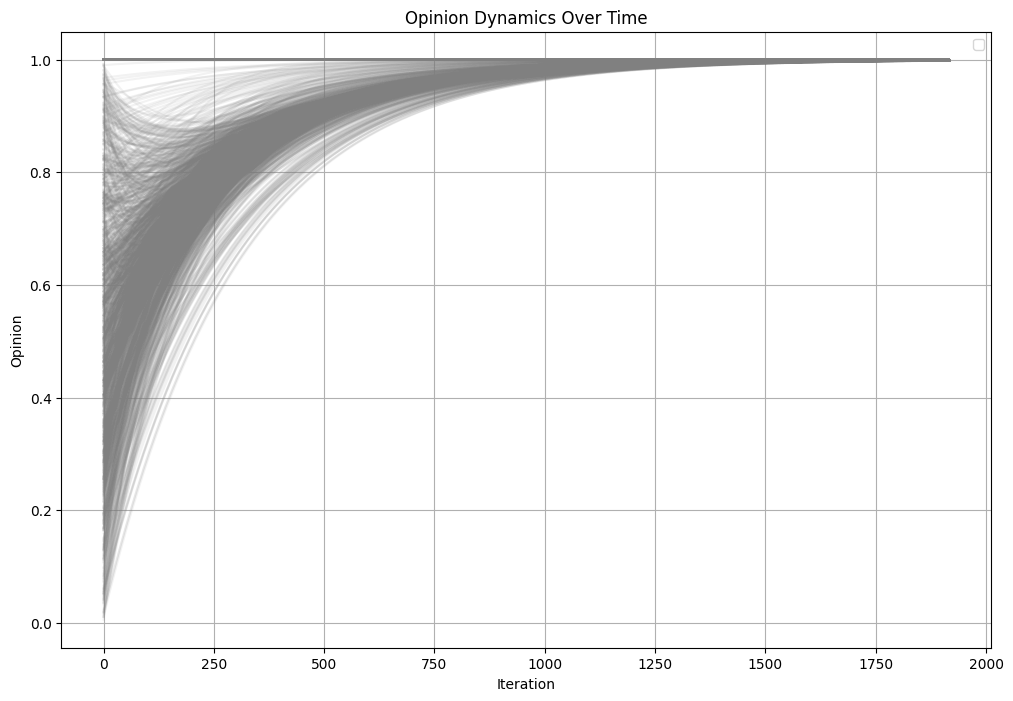

In [16]:
plot(opinion_history, max_iteration)

In [17]:
print(time_steps)

range(0, 1917)
